In [25]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm

In [26]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [27]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Привести к одному размеру
    transforms.ToTensor(),               # Превратить в тензор
    transforms.Normalize(
        mean=[0.462786465883255, 0.40768909454345703, 0.3523498475551605],
        std=[0.21254687011241913, 0.19136549532413483, 0.22076259553432465]
    )
])

train_dataset = datasets.ImageFolder(root='data/data/train', transform=transform)
test_dataset = datasets.ImageFolder(root='data/data/test', transform=transform)

classes = train_dataset.classes


train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=256, shuffle=False, pin_memory=True)



In [16]:

mean = torch.zeros(3)
std = torch.zeros(3)
total = 0

for images, labels in train_loader :
    batch_samples = images.size(0)
    images = images.view(batch_samples, 3, -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total += batch_samples

mean /= total
std /= total

print(f"Mean: {mean.tolist()}")
print(f"Std:  {std.tolist()}")


Mean: [0.4627867639064789, 0.40768906474113464, 0.3523499667644501]
Std:  [0.21254684031009674, 0.19136559963226318, 0.22076262533664703]


In [ ]:
class SimpsonModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.seq = nn.Sequential(

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 20),

        )
        
    def forward(self, x):
        return self.seq(x)


In [29]:
criterion = nn.CrossEntropyLoss()
model =  SimpsonModel().to(device)
opt = optim.Adam(model.parameters())

In [30]:
def train_step() -> float:
    model.train()
    
    running_loss = 0.
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.
        output = model(images)
        
        # Вычисляем функцию потерь на основе предсказания модели.
        loss = criterion(output, labels)

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        loss.backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def test_step() -> Tuple[float, float]:
    model.eval()

    correct_total = 0.
    running_loss = 0.
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            
            prediction = output.max(  # [bs, num_classes] -> [bs, 1]
                dim=1,
                keepdim=True,
            )[1] # # .argmax(dim=1)
            correct_total += prediction.eq(labels.view_as(prediction)).sum()
            
            loss = criterion(output, labels)
            running_loss += loss
        
    valid_loss = running_loss / len(test_loader)
    accuracy = correct_total / len(test_loader.dataset)
    return valid_loss.item(), accuracy.item()

In [37]:
train_losses = []
valid_losses = []
valid_accs = []

In [32]:
epochs = 20
model.to(device)  # model.to('cuda:0')

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step()
    valid_loss, valid_acc = test_step()
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train/valid loss: {train_loss:.4f}/{valid_loss:.4f}')

Avg. train/valid loss: 0.0972/0.1545: 100%|██████████| 20/20 [18:37<00:00, 55.87s/it]


Text(0, 0.5, 'Loss')

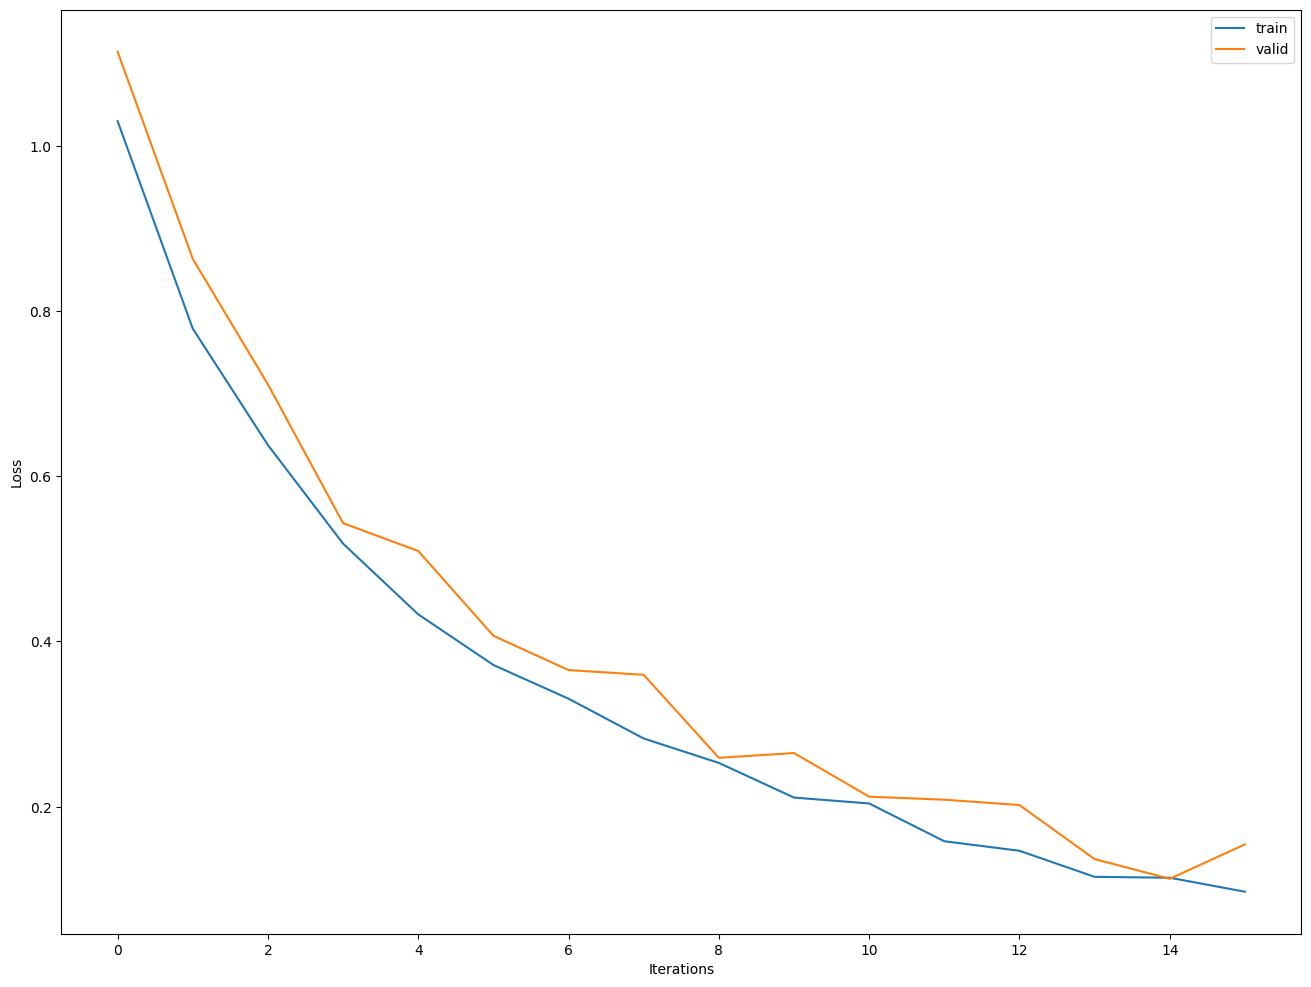

In [34]:
fig = plt.figure(figsize=(16, 12))

plt.plot(train_losses[4:], label='train')
plt.plot(valid_losses[4:], label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

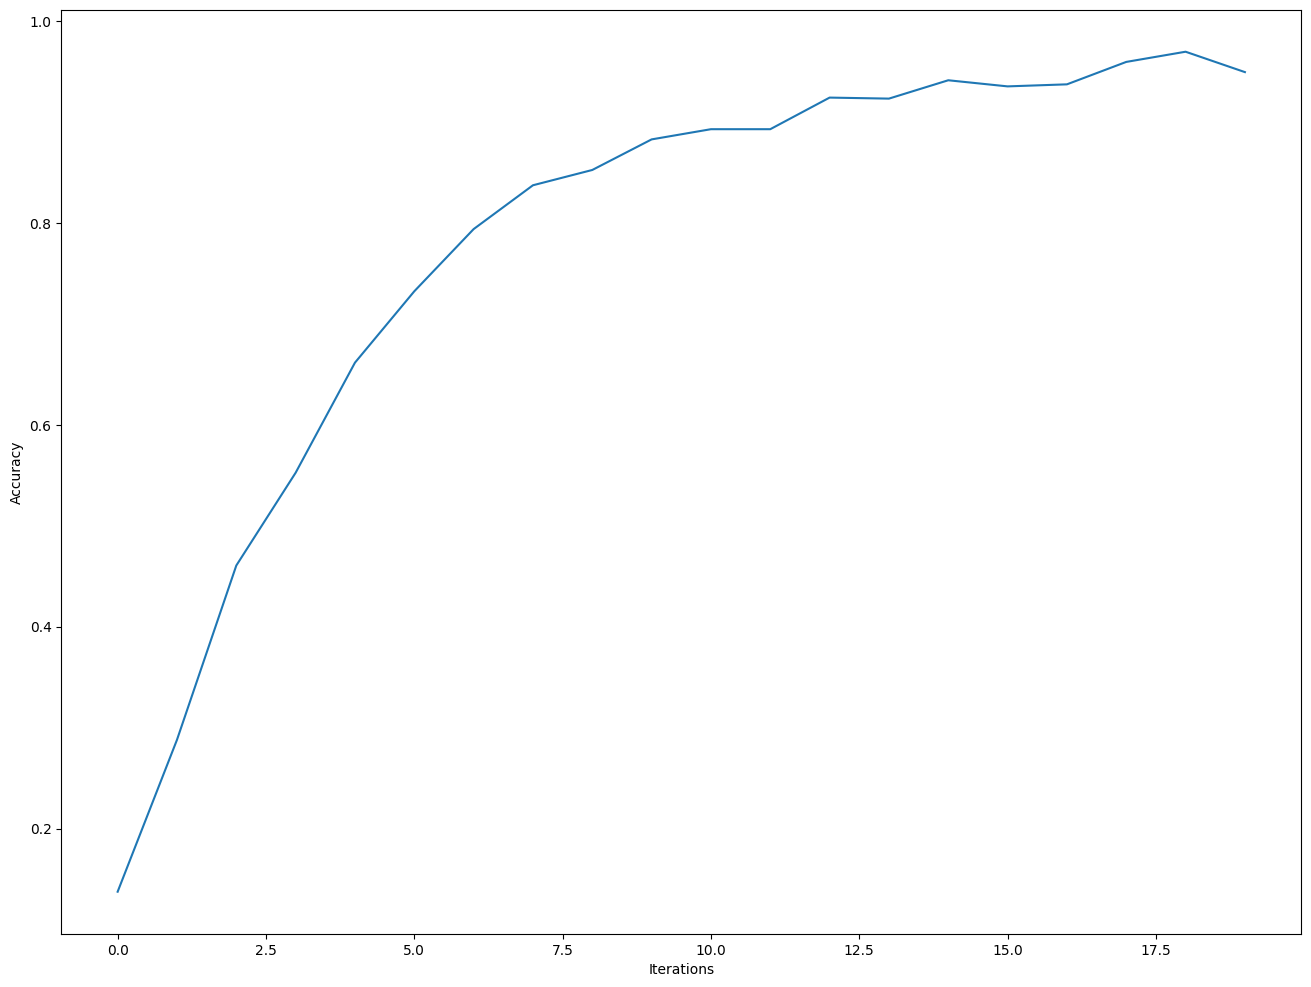

In [35]:
fig = plt.figure(figsize=(16, 12))

plt.plot(valid_accs)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')

In [36]:
torch.save(
    obj=model.state_dict(),
    f='weights.pt',
)